#  Exploration des Données - Ecommerce Pricing

## Contexte
Ce notebook est la première étape du projet d'optimisation des prix.  
On explore les données pour comprendre :
- La structure des tables disponibles
- La distribution des prix par catégorie
- La qualité des données (valeurs manquantes, anomalies)

In [1]:
# ============================================================
# IMPORTS DES BIBLIOTHÈQUES
# ============================================================
# pandas  : manipulation et analyse des données tabulaires
# numpy   : calculs mathématiques
# matplotlib / seaborn : visualisation des données

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Afficher toutes les colonnes dans les tableaux pandas
pd.set_option('display.max_columns', None)

print(" Bibliothèques importées avec succès")

 Bibliothèques importées avec succès


## 1. Chargement des données

Le dataset est composé de plusieurs tables reliées entre elles (comme une base de données).  
On charge ici les 4 tables les plus importantes pour notre analyse des prix :

| Table | Contenu |
|---|---|
| `orders` | Informations sur chaque commande |
| `items` | Produits achetés + **prix** |
| `products` | Catégories et caractéristiques des produits |
| `reviews` | Notes et avis des clients |

In [2]:
# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================
# On utilise pandas pour lire les fichiers CSV
# '../data/' signifie : remonter d'un dossier, puis aller dans 'data/'

orders   = pd.read_csv('../data/olist_orders_dataset.csv')
items    = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
reviews  = pd.read_csv('../data/olist_order_reviews_dataset.csv')

print(" Données chargées avec succès")
print(f"   - orders   : {orders.shape[0]:,} lignes, {orders.shape[1]} colonnes")
print(f"   - items    : {items.shape[0]:,} lignes, {items.shape[1]} colonnes")
print(f"   - products : {products.shape[0]:,} lignes, {products.shape[1]} colonnes")
print(f"   - reviews  : {reviews.shape[0]:,} lignes, {reviews.shape[1]} colonnes")

 Données chargées avec succès
   - orders   : 99,441 lignes, 8 colonnes
   - items    : 112,650 lignes, 7 colonnes
   - products : 32,951 lignes, 9 colonnes
   - reviews  : 99,224 lignes, 7 colonnes


- La table order qui est notre base de travail contient 99 441 commandes.
- On a 112 650 items (produits) plus que les commandes car une commande peut contenir plusieurs produits.
- On a dans la table product 32 951 produits différents.
- On a 99 224 avis donc presque une avis par commande.

## 2. Exploration de chaque table

On examine chaque table pour comprendre :
- Les colonnes disponibles et leur signification
- Les premières lignes pour voir à quoi ressemblent les données
- Les statistiques de base (min, max, moyenne...)
- Les valeurs manquantes

### 2.1 Table `items` — La plus importante

C'est la table centrale de notre projet car elle contient les **prix**.  
Chaque ligne = un produit acheté dans une commande.

In [3]:
# ============================================================
# EXPLORATION DE LA TABLE ITEMS
# ============================================================

print("=== Premières lignes de la table items ===")
print(items.head())

print("\n=== Colonnes disponibles ===")
print(items.columns.tolist())

=== Premières lignes de la table items ===
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3

### Statistiques sur les prix

On analyse la distribution des prix pour détecter :
- Le prix minimum et maximum
- Le prix moyen et médian
- Des anomalies (prix à 0, prix aberrants...)

In [4]:
# ============================================================
# STATISTIQUES SUR LES PRIX
# ============================================================

print("=== Statistiques sur les prix ===")
print(items['price'].describe().round(2))

print(f"\n Prix moyen    : {items['price'].mean():.2f} R$")
print(f" Prix médian   : {items['price'].median():.2f} R$")
print(f" Prix minimum  : {items['price'].min():.2f} R$")
print(f" Prix maximum  : {items['price'].max():.2f} R$")
print(f"\n  Produits à 0 R$ : {(items['price'] == 0).sum()}")

=== Statistiques sur les prix ===
count    112650.00
mean        120.65
std         183.63
min           0.85
25%          39.90
50%          74.99
75%         134.90
max        6735.00
Name: price, dtype: float64

 Prix moyen    : 120.65 R$
 Prix médian   : 74.99 R$
 Prix minimum  : 0.85 R$
 Prix maximum  : 6735.00 R$

  Produits à 0 R$ : 0


> **Observation** : L'écart-type des prix (183 R$) est bien supérieur à la moyenne (120 R$),  
> ce qui indique une forte dispersion. Cela confirme la nécessité d'analyser les prix  
> **par catégorie de produit** plutôt que globalement. Par exemple, comparer le prix d'un téléphone avec celui d'un stylo n'a aucun sens.

### Visualisation de la distribution des prix
 
On va visualiser la distribution des prix pour voir où se concentre la majorité des produits.  
On va limiter à 500 R$ pour mieux voir la distribution (les prix extrêmes écrasent le graphique).

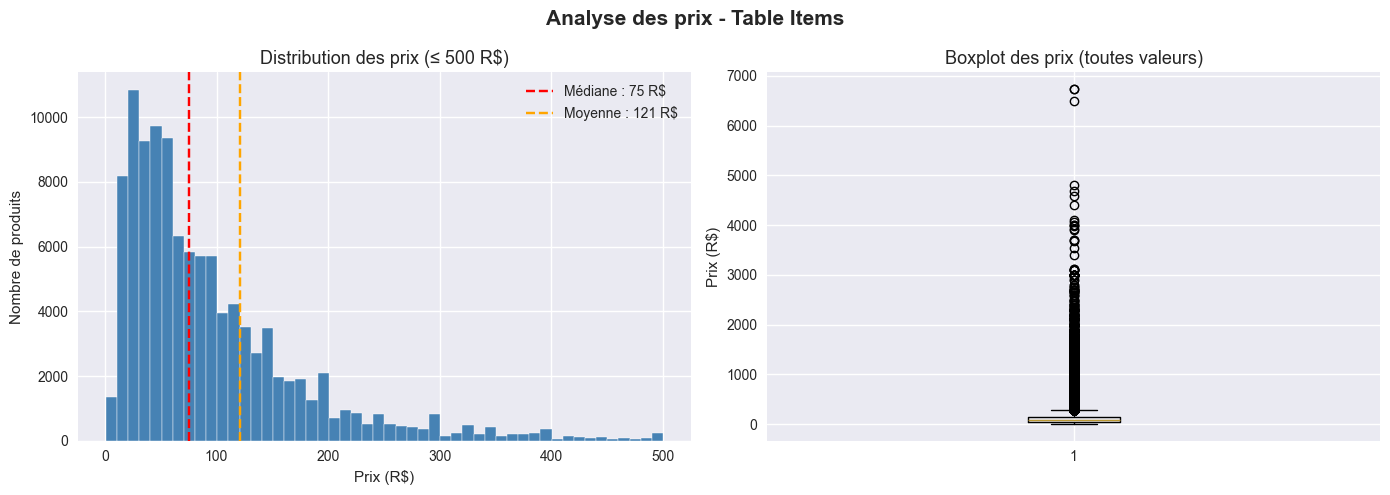

 Graphique sauvegardé dans outputs/


In [5]:
# ============================================================
# VISUALISATION DE LA DISTRIBUTION DES PRIX
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Distribution complète jusqu'à 500 R$ ---
# On filtre les prix > 500 R$ pour mieux voir la majorité des produits
axes[0].hist(items[items['price'] <= 500]['price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des prix (≤ 500 R$)', fontsize=13)
axes[0].set_xlabel('Prix (R$)')
axes[0].set_ylabel('Nombre de produits')

# Ligne verticale pour la médiane
axes[0].axvline(items['price'].median(), color='red', linestyle='--', label=f"Médiane : {items['price'].median():.0f} R$")
# Ligne verticale pour la moyenne
axes[0].axvline(items['price'].mean(), color='orange', linestyle='--', label=f"Moyenne : {items['price'].mean():.0f} R$")
axes[0].legend()

# --- Graphique 2 : Boxplot pour voir les extrêmes ---
# Le boxplot montre la médiane, les quartiles et les valeurs aberrantes
axes[1].boxplot(items['price'], vert=True)
axes[1].set_title('Boxplot des prix (toutes valeurs)', fontsize=13)
axes[1].set_ylabel('Prix (R$)')

plt.suptitle('Analyse des prix - Table Items', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/distribution_prix.png', dpi=150)
plt.show()

print(" Graphique sauvegardé dans outputs/")

> **Observations :**
> - Distribution fortement asymétrique à droite : la majorité des produits coûtent moins de 100 R$ . La médiane (rouge) est à gauche de la moyenne (orange), donc les produits chers tirent la moyenne vers le haut.
> - Nombreuses valeurs aberrantes au-delà de 500 R$ (visible sur le boxplot)
> - Médiane (75 R$) bien inférieure à la moyenne (121 R$) à cause des produits chers
> - Ces outliers confirment la nécessité d'analyser **par catégorie** et non globalement

### 2.2 Table `products`

Cette table contient les informations sur chaque produit.  
On va s'intéresser particulièrement à la colonne `product_category_name`  
car toute notre analyse sera faite **par catégorie**.

In [7]:
# ============================================================
# EXPLORATION DE LA TABLE PRODUCTS
# ============================================================

print("=== Premières lignes de la table products ===")
print(products.head())

print("\n=== Colonnes disponibles ===")
print(products.columns.tolist())

print(f"\n Nombre total de produits : {products.shape[0]:,}")
print(f" Nombre de catégories     : {products['product_category_name'].nunique()}")
print(f" Catégories manquantes    : {products['product_category_name'].isna().sum()}")

=== Premières lignes de la table products ===
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0 

### Top des catégories par nombre de produits

On regarde quelles catégories contiennent le plus de produits.  
Cela nous aidera à identifier les catégories avec assez de données  
pour calculer une élasticité prix fiable.

=== Top 15 catégories ===
                      categorie  nb_produits
0               cama_mesa_banho         3029
1                 esporte_lazer         2867
2              moveis_decoracao         2657
3                  beleza_saude         2444
4         utilidades_domesticas         2335
5                    automotivo         1900
6        informatica_acessorios         1639
7                    brinquedos         1411
8            relogios_presentes         1329
9                     telefonia         1134
10                        bebes          919
11                   perfumaria          868
12                    papelaria          849
13  fashion_bolsas_e_acessorios          849
14                   cool_stuff          789


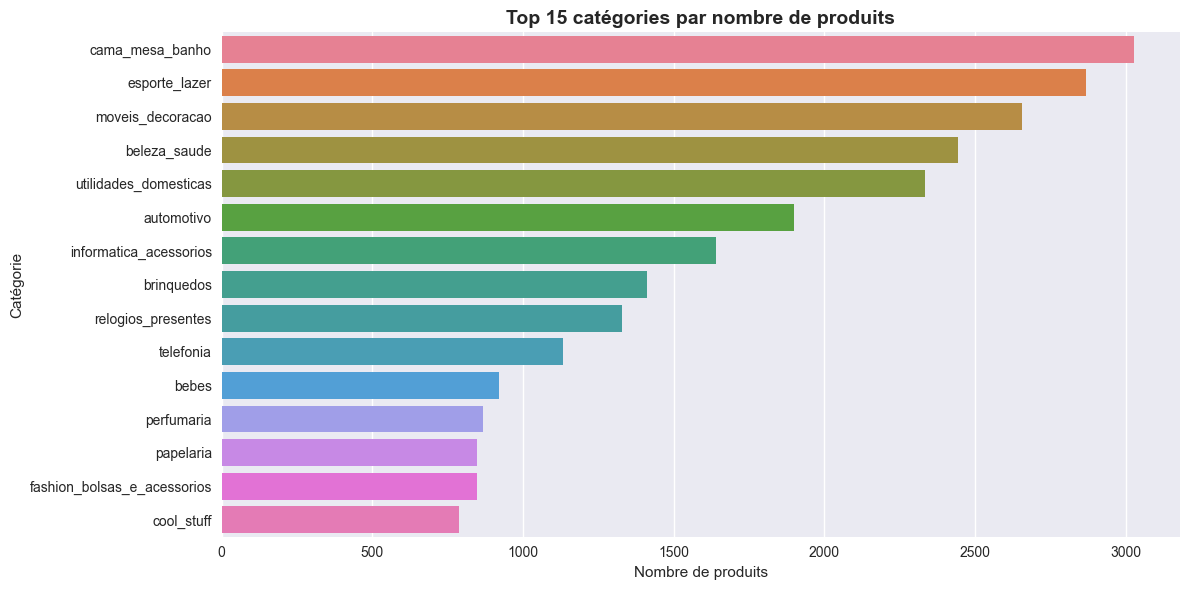

 Graphique sauvegardé dans outputs/


In [9]:
# ============================================================
# TOP 15 CATÉGORIES PAR NOMBRE DE PRODUITS
# ============================================================

# Compter le nombre de produits par catégorie et trier
top_categories = (products['product_category_name']
                  .value_counts()
                  .head(15)
                  .reset_index())

top_categories.columns = ['categorie', 'nb_produits']

# Afficher le tableau
print("=== Top 15 catégories ===")
print(top_categories)

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='nb_produits', y='categorie', hue='categorie', legend=False)
plt.title('Top 15 catégories par nombre de produits', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de produits')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.savefig('../outputs/top_categories.png', dpi=150)
plt.show()

print(" Graphique sauvegardé dans outputs/")

> **Observations :**
> - 73 catégories au total, les catégories sont en portugais
> - Les catégories les plus représentées sont : literie, sport, meubles, beauté
> - Ces catégories avec 1000+ produits seront idéales pour calculer l'élasticité prix

### 2.3 Fusion des tables items + products

Pour analyser les prix par catégorie, on doit relier :
- La table `items` qui contient les **prix**
- La table `products` qui contient les **catégories**

Le lien entre les deux tables est la colonne `product_id`.

In [10]:
# ============================================================
# FUSION ITEMS + PRODUCTS
# ============================================================

# On relie les deux tables via la colonne commune 'product_id'
# how='left' : on garde tous les items, même sans catégorie
df = items.merge(products[['product_id', 'product_category_name']], 
                 on='product_id', 
                 how='left')

print(f" Fusion réussie")
print(f"   - Lignes avant fusion : {items.shape[0]:,}")
print(f"   - Lignes après fusion : {df.shape[0]:,}")
print(f"   - Colonnes disponibles : {df.columns.tolist()}")
print(f"\n  Produits sans catégorie : {df['product_category_name'].isna().sum():,}")

 Fusion réussie
   - Lignes avant fusion : 112,650
   - Lignes après fusion : 112,650
   - Colonnes disponibles : ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name']

  Produits sans catégorie : 1,603


> **Observation :**  
> La fusion est parfaite (112 650 lignes conservées).  
> Dans products on avait 610 produits sans catégorie et maintenangt 1 603 items sans catégorie car un même produit peut apparaître dans plusieurs commandes. 

### 2.4 Prix moyen par catégorie

Maintenant qu'on a les prix et les catégories ensemble,  
on va voir quelles catégories ont les prix les plus élevés.  
C'est une première indication sur où se trouvent les opportunités d'optimisation.

=== Top 15 catégories par prix moyen ===
                         product_category_name  prix_moyen  prix_median  nb_ventes
                                           pcs     1098.34      1100.00        203
                   portateis_casa_forno_e_cafe      624.29       587.00         76
                            eletrodomesticos_2      476.12       225.94        238
                     agro_industria_e_comercio      342.12       258.65        212
                         instrumentos_musicais      281.62        94.84        680
                               eletroportateis      280.78        99.00        679
 portateis_cozinha_e_preparadores_de_alimentos      264.57        34.90         15
                                telefonia_fixa      225.69        64.48        264
              construcao_ferramentas_seguranca      208.99       125.58        194
                            relogios_presentes      201.14       129.00       5991
                                  climatizacao

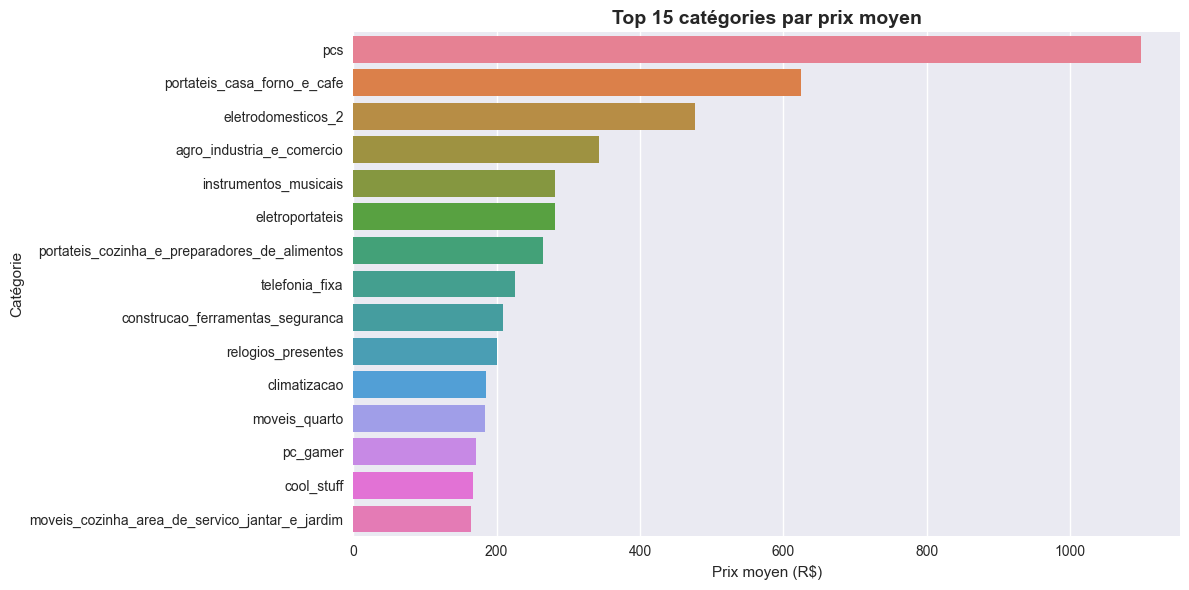

 Graphique sauvegardé dans outputs/


In [11]:
# ============================================================
# PRIX MOYEN PAR CATÉGORIE (Top 15)
# ============================================================

# Calculer le prix moyen et le nombre de ventes par catégorie
prix_par_categorie = (df.groupby('product_category_name')
                       .agg(
                           prix_moyen=('price', 'mean'),
                           prix_median=('price', 'median'),
                           nb_ventes=('order_id', 'count')
                       )
                       .round(2)
                       .sort_values('prix_moyen', ascending=False)
                       .reset_index())

# Afficher le top 15
print("=== Top 15 catégories par prix moyen ===")
print(prix_par_categorie.head(15).to_string(index=False))

# Visualisation
plt.figure(figsize=(12, 6))
sns.barplot(data=prix_par_categorie.head(15), 
            x='prix_moyen', 
            y='product_category_name',
            hue='product_category_name',
            legend=False)
plt.title('Top 15 catégories par prix moyen', fontsize=14, fontweight='bold')
plt.xlabel('Prix moyen (R$)')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.savefig('../outputs/prix_moyen_par_categorie.png', dpi=150)
plt.show()

print(" Graphique sauvegardé dans outputs/")

> **Observations :**
> - Les catégories les plus chères sont liées à l'électronique (pcs, électroménager)
> - Certaines catégories ont un grand écart moyenne/médiane donc une forte dispersion des prix
> - Les catégories avec beaucoup de ventes et prix cohérents (relogios_presentes, cool_stuff)
>   seront privilégiées pour le calcul d'élasticité
> - Catégories avec < 100 ventes (pc_gamer: 9, portateis_cozinha: 15) ont trop peu de données

### 2.5 Table `orders` — Statut des commandes

On vérifie les différents statuts de commandes disponibles.  
Pour notre analyse, on ne gardera que les commandes **livrées** (`delivered`)  
car ce sont les seules qui représentent de vraies transactions finalisées.

In [12]:
# ============================================================
# EXPLORATION DE LA TABLE ORDERS
# ============================================================

print("=== Statuts des commandes ===")
statuts = orders['order_status'].value_counts()
print(statuts)

print(f"\n Commandes livrées    : {statuts.get('delivered', 0):,}")
print(f" Commandes non livrées : {orders.shape[0] - statuts.get('delivered', 0):,}")
print(f" % commandes livrées  : {statuts.get('delivered', 0) / orders.shape[0] * 100:.1f}%")

=== Statuts des commandes ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

 Commandes livrées    : 96,478
 Commandes non livrées : 2,963
 % commandes livrées  : 97.0%


> **Observations :**
> - 97% des commandes sont livrées.
> - On ne gardera que les 96 478 commandes "delivered" pour notre analyse
> - Les commandes annulées, en cours, ou non disponibles seront exclues lors du nettoyage. Ils sont pas important pour notre analyse d'optimisation des prix.

### 2.6 Table `reviews` — Avis clients

Les avis clients nous donnent une indication sur la satisfaction.  
Une note faible malgré un prix élevé peut signifier que le produit est surcoté.  
On vérifie la distribution des notes.

=== Distribution des notes ===
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

 Note moyenne   : 4.09 / 5
 Note médiane   : 5 / 5
 Avis manquants : 0


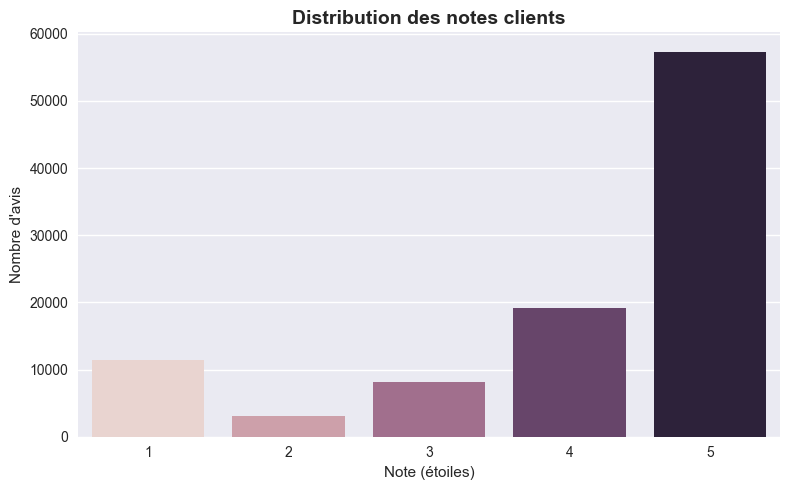

 Graphique sauvegardé dans outputs/


In [13]:
# ============================================================
# EXPLORATION DE LA TABLE REVIEWS
# ============================================================

print("=== Distribution des notes ===")
notes = reviews['review_score'].value_counts().sort_index()
print(notes)

print(f"\n Note moyenne   : {reviews['review_score'].mean():.2f} / 5")
print(f" Note médiane   : {reviews['review_score'].median():.0f} / 5")
print(f" Avis manquants : {reviews['review_score'].isna().sum()}")

# Visualisation
plt.figure(figsize=(8, 5))
sns.barplot(x=notes.index, y=notes.values, hue=notes.index, legend=False)
plt.title('Distribution des notes clients', fontsize=14, fontweight='bold')
plt.xlabel('Note (étoiles)')
plt.ylabel('Nombre d\'avis')
plt.tight_layout()
plt.savefig('../outputs/distribution_notes.png', dpi=150)
plt.show()

print(" Graphique sauvegardé dans outputs/")

> **Observations :**
> - 57 328 notes à 5 étoiles donc la majorité des clients sont très satisfaits.
> - Note moyenne de 4.09/5 donc les clients sont  globalement satisfaits
> - Médiane à 5 donc plus de la moitié des clients donnent la note maximale
> - Pic de notes 1 étoile (11 424) qu'on va éssayé de comprendre : produits trop chers ? qualité insuffisante ?
> - Aucune valeur manquante.

## 3. Conclusion de l'exploration

On fait le bilan de tout ce qu'on a découvert avant de passer au nettoyage.

In [16]:
# ============================================================
# BILAN DE L'EXPLORATION
# ============================================================

print("=" * 55)
print("      BILAN DE L'EXPLORATION DES DONNÉES")
print("=" * 55)

print(f"""
 VOLUME DES DONNÉES
   - {orders.shape[0]:,} commandes dont {orders['order_status'].value_counts()['delivered']:,} livrées (97%)
   - {items.shape[0]:,} produits achetés
   - {products.shape[0]:,} produits uniques en {products['product_category_name'].nunique()} catégories
   - {reviews.shape[0]:,} avis clients

 PRIX
   - Prix moyen  : {items['price'].mean():.2f} R$
   - Prix médian : {items['price'].median():.2f} R$
   - Prix min    : {items['price'].min():.2f} R$
   - Prix max    : {items['price'].max():.2f} R$

 SATISFACTION
   - Note moyenne : {reviews['review_score'].mean():.2f} / 5
   """)

      BILAN DE L'EXPLORATION DES DONNÉES

 VOLUME DES DONNÉES
   - 99,441 commandes dont 96,478 livrées (97%)
   - 112,650 produits achetés
   - 32,951 produits uniques en 73 catégories
   - 99,224 avis clients

 PRIX
   - Prix moyen  : 120.65 R$
   - Prix médian : 74.99 R$
   - Prix min    : 0.85 R$
   - Prix max    : 6735.00 R$

 SATISFACTION
   - Note moyenne : 4.09 / 5
   


## 4. Conclusions 
### Ce qu'on a appris
- Dataset de qualité : 97% des commandes sont livrées, aucun avis manquant
- Les prix sont très dispersés (std : 183 R$) → analyse obligatoirement par catégorie
- 73 catégories disponibles, les plus volumineuses ont 1000+ produits
- Les clients sont globalement satisfaits (4.09/5)

### Problèmes identifiés à corriger
| Problème | Action prévue |
|---|---|
| 1 603 items sans catégorie | Suppression dans notebook 02 |
| 2 963 commandes non livrées | Filtrage sur `delivered` dans notebook 02 |
| Prix très dispersés | Travail par catégorie dès notebook 03 |
| Catégories en portugais | Traduction dans notebook 02 |

### Prochaine étape
➡️ `02_nettoyage.ipynb` : nettoyage et préparation des données pour la modélisation